# 04 - Wizualizacje finalne

Czyste, dopracowane wykresy eksportowane do `reports/figures/`.

| # | Wykres | Plik |
|---|--------|------|
| 1 | Czas przejazdu w zaleznosci od kierunku i godziny | `01_kierunek_vs_godzina.png` |
| 2 | Czas przejazdu per trasa - kierunek A | `02_trasy_kierunek_a.png` |
| 3 | Czas przejazdu per dzien tygodnia - kierunek A | `03_dni_tygodnia_kierunek_a.png` |
| 4 | Sredni czas przejazdu wg godziny - kierunek A | `04_godziny_kierunek_a.png` |
| 5 | Czas przejazdu: weekend vs dzien roboczy | `05_weekend_vs_tydzien.png` |

## Importy i konfiguracja

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

df = pd.read_csv('../data/processed/traveltime_clean.csv')
df['Date'] = pd.to_datetime(df['Date'])
df['Hour'] = pd.to_datetime(df['Measurement_Time'], format='%H:%M').dt.hour
df['Is_Weekend'] = df['Date'].dt.dayofweek >= 5

print(f'Wczytano {len(df):,} rekordow')

Wczytano 44,588 rekordow


---
## Wykres 1 - Czas przejazdu w zaleznosci od kierunku i godziny

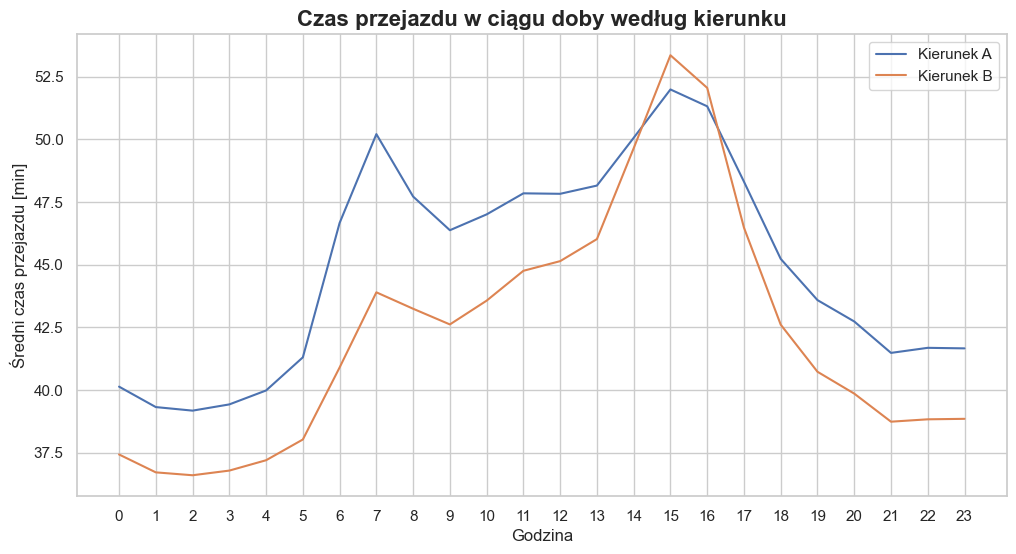

In [66]:
df['Hour'] = pd.to_datetime(df['Measurement_Time'], format='%H:%M').dt.hour
hourly = df.groupby(['Hour', 'Direction'])['Duration_Min'].mean().reset_index()

plt.plot(hourly[hourly['Direction'] == 'A']['Hour'], hourly[hourly['Direction'] == 'A']['Duration_Min'])
plt.plot(hourly[hourly['Direction'] == 'B']['Hour'], hourly[hourly['Direction'] == 'B']['Duration_Min'])
plt.xlabel('Godzina')
plt.ylabel('Średni czas przejazdu [min]')
plt.xticks(range(0, 24))
plt.grid(True)
plt.title('Czas przejazdu w ciągu doby według kierunku', fontsize=16, fontweight='bold')
plt.legend(['Kierunek A', 'Kierunek B'])
plt.savefig('../reports/figures/01_kierunek_vs_godzina.png', dpi=150, bbox_inches='tight')


---
## Wykres 2 - Czas przejazdu per trasa - kierunek A

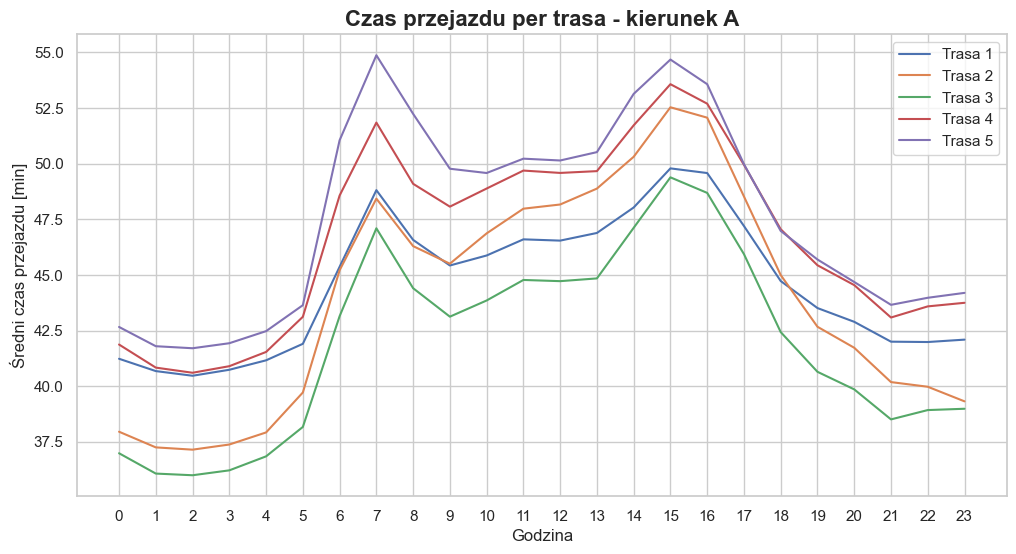

In [67]:
hourly = df.groupby(['Hour', 'Direction', 'Route_Id'])['Duration_Min'].mean().reset_index()

for route_id in sorted(df['Route_Id'].unique()):
    subset = hourly[(hourly['Direction'] == 'A') & (hourly['Route_Id'] == route_id)]
    plt.plot(subset['Hour'], subset['Duration_Min'], label=f'Trasa {route_id}')

plt.xlabel('Godzina')
plt.ylabel('Średni czas przejazdu [min]')
plt.xticks(range(0, 24))
plt.title('Czas przejazdu per trasa - kierunek A', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True)
plt.savefig('../reports/figures/02_trasy_kierunek_a.png', dpi=150, bbox_inches='tight')


---
## Wykres 3 - Czas przejazdu per dzien tygodnia - kierunek A

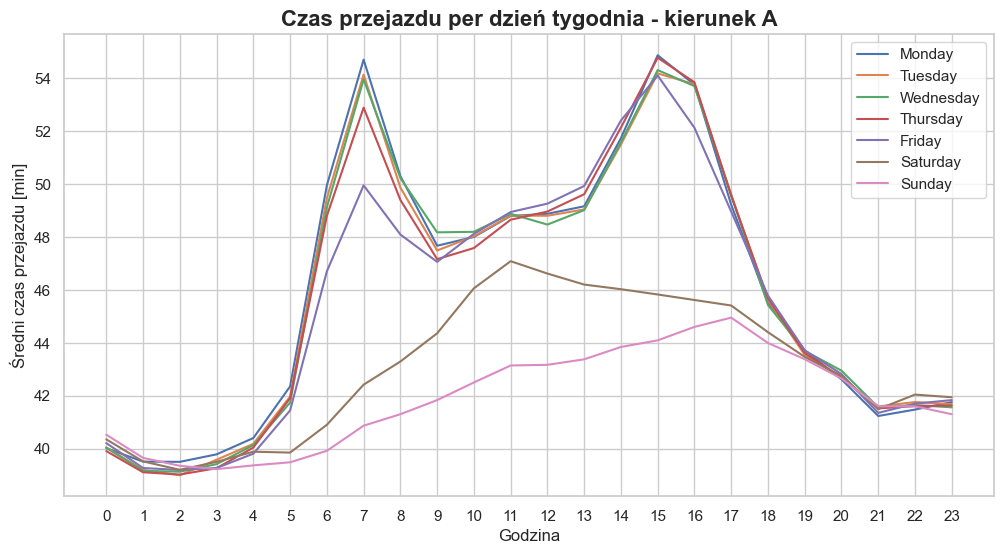

In [68]:
kolejnosc_dni = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['Day_Of_Week'] = pd.Categorical(df['Day_Of_Week'], categories=kolejnosc_dni, ordered=True)

hourly = df.groupby(['Hour', 'Direction', 'Day_Of_Week'], observed=True)['Duration_Min'].mean().reset_index()

for day in kolejnosc_dni:
    subset = hourly[(hourly['Direction'] == 'A') & (hourly['Day_Of_Week'] == day)]
    plt.plot(subset['Hour'], subset['Duration_Min'], label=f'{day}')

plt.xlabel('Godzina')
plt.ylabel('Średni czas przejazdu [min]')
plt.xticks(range(0, 24))
plt.title('Czas przejazdu per dzień tygodnia - kierunek A', fontsize=16, fontweight='bold')
plt.legend()
plt.grid(True)
plt.savefig('../reports/figures/03_dni_tygodnia_kierunek_a.png', dpi=150, bbox_inches='tight')


---
## Wykres 4 - Sredni czas przejazdu wg godziny - kierunek A

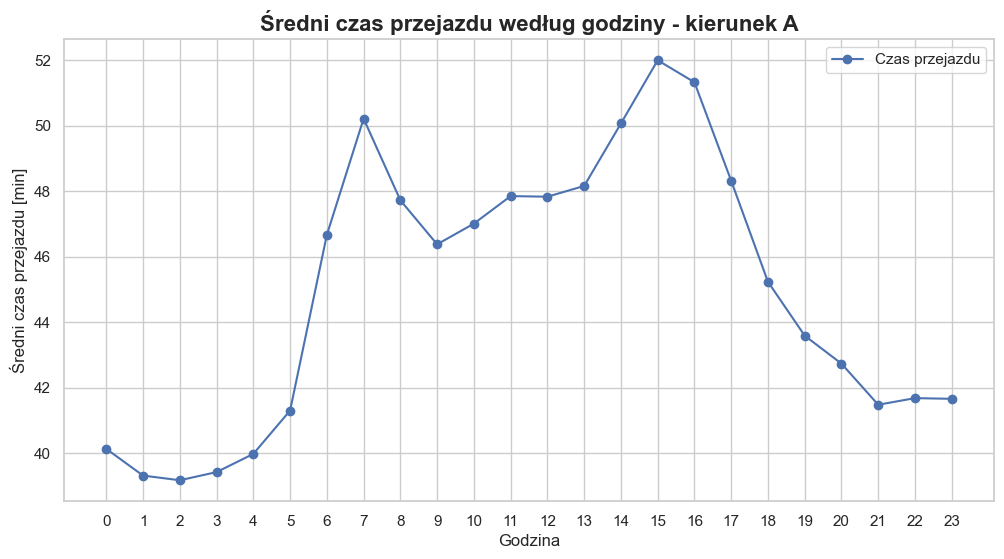

In [69]:
df[df['Direction'] == 'A'].groupby('Hour').agg({'Duration_Min': 'mean', 'Delay_Min': 'mean'}).reset_index().plot(x='Hour', y='Duration_Min', kind='line', marker='o')
plt.xlabel('Godzina')
plt.ylabel('Średni czas przejazdu [min]')
plt.legend(['Czas przejazdu'])
plt.title('Średni czas przejazdu według godziny - kierunek A', fontsize=16, fontweight='bold')
plt.xticks(range(0, 24))
plt.grid(True)
plt.savefig('../reports/figures/04_godziny_kierunek_a.png', dpi=150, bbox_inches='tight')


---
## Wykres 5 - Czas przejazdu: weekend vs dzien roboczy

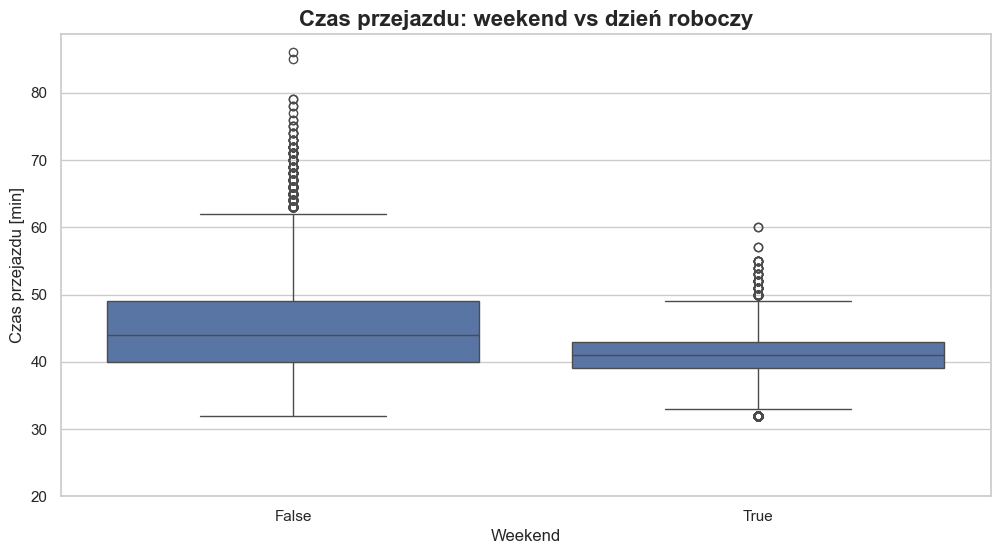

In [70]:
sns.boxplot(x='Is_Weekend', y='Duration_Min', data=df)
plt.xlabel('Weekend')
plt.ylabel('Czas przejazdu [min]')
plt.title('Czas przejazdu: weekend vs dzień roboczy', fontsize=16, fontweight='bold')
plt.suptitle('')
plt.yticks(range(20, 90, 10))
plt.savefig('../reports/figures/05_weekend_vs_tydzien.png', dpi=150, bbox_inches='tight')
